# JAX CTDS vs. NumPy CTDS — apples-to-apples comparison

Mirrors `jax_vs_numpy_lds.ipynb` for the constrained model. Both `CTDS` and `CTDSJax` route the constrained M-steps (`update_A`, `update_A_B`, `update_C`) through cvxpy/MOSEK, so QP-derived params should match within solver tolerance (~1e-6) rather than the ~1e-13 we got for the pure linear-algebra LDS updates.

1. E-step: filter outputs (means, covs, LL) — inherited from LDS, expect ~1e-13
2. E-step: smoother outputs
3. Single M-step from identical sufficient stats — QP outputs at MOSEK tolerance
4. Full EM: LL trajectory and final params
5. Aligned param recovery (same protocol as `ctds_param_recovery.ipynb`)
6. With inputs (B updated jointly with A via QP, no feedthrough)
7. Wall-clock timing

In [1]:
from jax import config
config.update('jax_enable_x64', True)  # match numpy float64

import time
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from pillow_lab_rotation import ctds as ctds_np
from pillow_lab_rotation import jax_ctds as ctds_jx
from pillow_lab_rotation.simulate import CTDSSim, generate_gaussian_inputs

plt.style.use('../JS.mplstyle')

## Helpers

In [2]:
def set_params_np(model, params):
    A, C, Q, Q0, mu0, R, *rest = params
    model.A, model.C = A.copy(), C.copy()
    model.Q, model.Q0 = Q.copy(), Q0.copy()
    model.mu0, model.R = mu0.copy(), R.copy()
    if rest:
        model.B = rest[0].copy()
    return model

def set_params_jx(model, params):
    A, C, Q, Q0, mu0, R, *rest = params
    model.A, model.C = jnp.asarray(A), jnp.asarray(C)
    model.Q, model.Q0 = jnp.asarray(Q), jnp.asarray(Q0)
    model.mu0, model.R = jnp.asarray(mu0), jnp.asarray(R)
    if rest:
        model.B = jnp.asarray(rest[0])
    return model

def maxabs(a, b):
    return float(np.max(np.abs(np.asarray(a) - np.asarray(b))))

def report(name, np_arr, jx_arr):
    err = maxabs(np_arr, jx_arr)
    print(f'  {name:<14s} max|np-jx| = {err:.3e}')
    return err

## Generate ground-truth model + data

In [3]:
De, Di = 2, 2
Ne, Ni = 4, 4
D_lat = De + Di
N = Ne + Ni
T = 100
n_trials = 200

sim = CTDSSim(De, Di, Ne, Ni)
np.random.seed(42)
sim.create_params()
true_params = sim.get_params()  # (A, C, Q, Q0, mu0, R)

_, Y = sim.simulate(T, n_trials)
Y_jx = jnp.asarray(Y)
Y.shape

(200, 100, 8, 1)

## 1. Filter outputs match

E-step is fully inherited from the LDS in both implementations, so this should match the LDS notebook to ~1e-13.

In [4]:
m_np = ctds_np.CTDS(De, Di, Ne, Ni)
m_jx = ctds_jx.CTDSJax(De, Di, Ne, Ni)
set_params_np(m_np, true_params)
set_params_jx(m_jx, true_params)

m_np.observations = Y
m_np.n_trials, m_np.T = n_trials, T
m_np.inputs = np.zeros((n_trials, T, 0, 1))
m_np.run_filter()

m_jx.observations = Y_jx
m_jx.n_trials, m_jx.T = n_trials, T
m_jx.inputs = jnp.zeros((n_trials, T, 0, 1))
m_jx.run_filter()

print('Filter:')
report('x_predicted', m_np.x_predicted, m_jx.x_predicted)
report('x_filtered',  m_np.x_filtered,  m_jx.x_filtered)
report('P_predicted', m_np.P_predicted, m_jx.P_predicted)
report('P_filtered',  m_np.P_filtered,  m_jx.P_filtered)
report('LL',          m_np.LL,          m_jx.LL)

Filter:
  x_predicted    max|np-jx| = 1.998e-15
  x_filtered     max|np-jx| = 3.553e-15
  P_predicted    max|np-jx| = 8.882e-16
  P_filtered     max|np-jx| = 2.665e-15
  LL             max|np-jx| = 0.000e+00


0.0

## 2. Smoother outputs match

In [5]:
m_np.run_smoother()
m_jx.run_smoother()

print('Smoother:')
report('m',       m_np.m,       m_jx.m)
report('sigma',   m_np.sigma,   m_jx.sigma)
report('sigma_x', m_np.sigma_x, m_jx.sigma_x)

Smoother:
  m              max|np-jx| = 3.553e-15
  sigma          max|np-jx| = 2.442e-15
  sigma_x        max|np-jx| = 8.882e-16


8.881784197001252e-16

## 3. Single M-step from identical sufficient stats

`A` and `C` are MOSEK QP solutions, so expect agreement at solver tolerance (~1e-6 to 1e-8). `Q`, `Q0`, `mu0`, `R` use the LDS closed-form updates and should match much tighter.

In [6]:
m_np._get_sufficient_stats()
m_jx._get_sufficient_stats()

print('Sufficient stats:')
for name in ['M11', 'M2T', 'M1Tm1', 'M1T', 'M_delta', 'Y', 'Y_hat']:
    report(name, getattr(m_np, name), getattr(m_jx, name))

m_np.m_step(); m_jx.m_step()

print('\nUpdated params:')
for name in ['A', 'C', 'Q', 'Q0', 'mu0', 'R']:
    report(name, getattr(m_np, name), getattr(m_jx, name))

Sufficient stats:
  M11            max|np-jx| = 1.478e-12
  M2T            max|np-jx| = 1.171e-08
  M1Tm1          max|np-jx| = 1.179e-08
  M1T            max|np-jx| = 1.171e-08
  M_delta        max|np-jx| = 3.682e-09
  Y              max|np-jx| = 4.366e-11
  Y_hat          max|np-jx| = 1.455e-11

Updated params:
  A              max|np-jx| = 6.056e-11
  C              max|np-jx| = 1.634e-09
  Q              max|np-jx| = 5.658e-13
  Q0             max|np-jx| = 7.105e-15
  mu0            max|np-jx| = 4.441e-16
  R              max|np-jx| = 1.470e-13


## 4. Full EM: LL curve and final params

LL trajectory max|np-jx| = 5.176e-11
Final iter LL np = -14.376447, jx = -14.376447

Final params:
  A              max|np-jx| = 3.731e-08
  C              max|np-jx| = 4.498e-08
  Q              max|np-jx| = 8.005e-08
  Q0             max|np-jx| = 1.316e-07
  mu0            max|np-jx| = 5.464e-08
  R              max|np-jx| = 3.439e-09


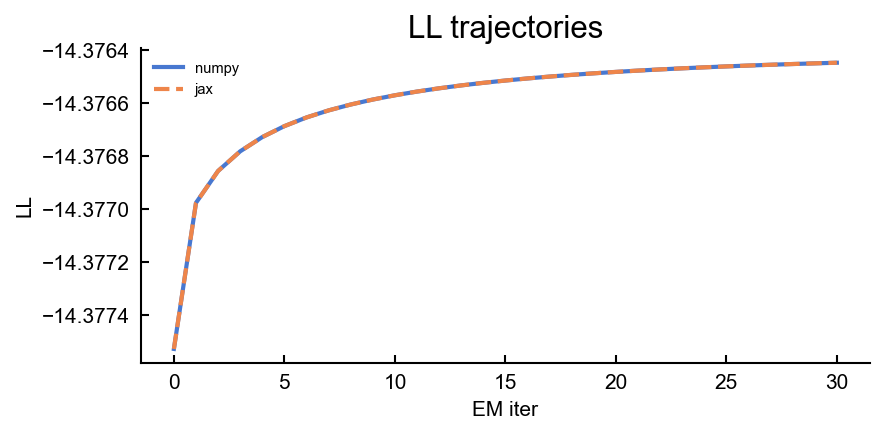

In [7]:
max_iter = 30

m_np = ctds_np.CTDS(De, Di, Ne, Ni)
m_jx = ctds_jx.CTDSJax(De, Di, Ne, Ni)
set_params_np(m_np, true_params)
set_params_jx(m_jx, true_params)

m_np.fit(Y, max_iter=max_iter)
m_jx.fit(Y_jx, max_iter=max_iter)

ll_np = np.array(m_np.ll_history)
ll_jx = np.array(m_jx.ll_history)
print(f'LL trajectory max|np-jx| = {np.max(np.abs(ll_np - ll_jx)):.3e}')
print(f'Final iter LL np = {ll_np[-1]:.6f}, jx = {ll_jx[-1]:.6f}')

print('\nFinal params:')
for name in ['A', 'C', 'Q', 'Q0', 'mu0', 'R']:
    report(name, getattr(m_np, name), getattr(m_jx, name))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ll_np, label='numpy', lw=2)
ax.plot(ll_jx, label='jax', ls='--', lw=2)
ax.set_xlabel('EM iter'); ax.set_ylabel('LL')
ax.set_title('LL trajectories'); ax.legend()
plt.show()

## 5. Aligned param recovery (both implementations on the same trial counts)

Same protocol as `ctds_param_recovery.ipynb`: init both at the true params, fit, then align via $H = (C'^T C')^{-1} C'^T C_{true}$ and compare aligned MSEs.

In [8]:
De_r, Di_r = 2, 3
Ne_r, Ni_r = 5, 5
T_r = 50
trial_list = [50, 100, 200, 500, 1000, 2000]

sim_r = CTDSSim(De_r, Di_r, Ne_r, Ni_r)
np.random.seed(42)
sim_r.create_params()
A_t, C_t, Q_t, Q0_t, mu0_t, R_t = sim_r.get_params()
_, Y_r = sim_r.simulate(T_r, trial_list[-1])
Y_r_jx = jnp.asarray(Y_r)

def fit_one(model_factory, set_fn, Y_data, n):
    model = model_factory()
    set_fn(model, (A_t, C_t, Q_t, Q0_t, mu0_t, R_t))
    model.fit(Y_data[:n], max_iter=30)
    return model

def aligned_losses(model):
    A, C, Q, R = (np.asarray(model.A), np.asarray(model.C),
                  np.asarray(model.Q), np.asarray(model.R))
    H = np.linalg.inv(C.T @ C) @ C.T @ C_t
    H_inv = np.linalg.inv(H)
    return {
        'A': np.mean((H_inv @ A @ H - A_t)**2),
        'C': np.mean((C @ H - C_t)**2),
        'Q': np.mean((H_inv @ Q @ H_inv.T - Q_t)**2),
        'R': np.mean((R - R_t)**2),
    }

results = {'np': {k: [] for k in 'ACQR'},
           'jx': {k: [] for k in 'ACQR'}}
for n in trial_list:
    print(f'n_trials = {n}')
    mn = fit_one(lambda: ctds_np.CTDS(De_r, Di_r, Ne_r, Ni_r), set_params_np, Y_r,    n)
    mj = fit_one(lambda: ctds_jx.CTDSJax(De_r, Di_r, Ne_r, Ni_r), set_params_jx, Y_r_jx, n)
    for k, v in aligned_losses(mn).items(): results['np'][k].append(v)
    for k, v in aligned_losses(mj).items(): results['jx'][k].append(v)

n_trials = 50
n_trials = 100
n_trials = 200
n_trials = 500
n_trials = 1000
n_trials = 2000


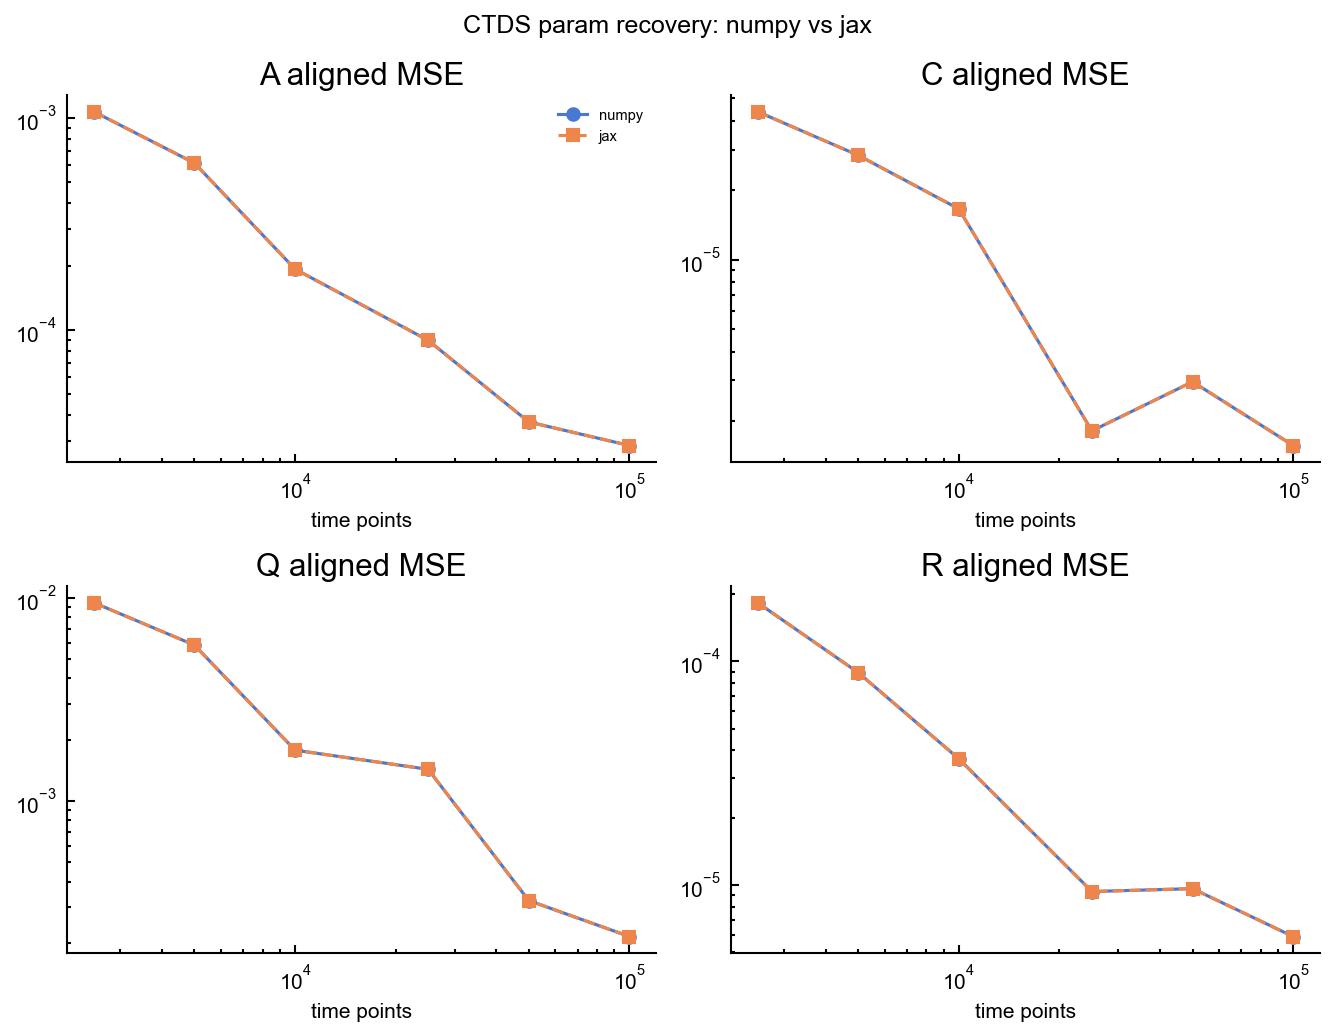

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
x_axis = T_r * np.array(trial_list)
for ax, name in zip(axes.flat, ['A', 'C', 'Q', 'R']):
    ax.plot(x_axis, results['np'][name], 'o-', label='numpy')
    ax.plot(x_axis, results['jx'][name], 's--', label='jax')
    ax.set_title(f'{name} aligned MSE')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('time points')
axes[0, 0].legend()
fig.suptitle('CTDS param recovery: numpy vs jax')
fig.tight_layout()
plt.show()

## 6. With inputs (B, no feedthrough)

CTDS pins `feedthrough=False`, so `D` is always zero. With `udim > 0`, both implementations call `update_A_B` which solves a single QP over `vec([A, B])` with sign constraints on the A portion.

In [10]:
udim = 2
sim_u = CTDSSim(De, Di, Ne, Ni, udim=udim)
np.random.seed(7)
sim_u.create_params()
params_u = sim_u.get_params()  # (A, C, Q, Q0, mu0, R, B)
U_full = generate_gaussian_inputs(n_trials, T, udim)
_, Y_u = sim_u.simulate(T, n_trials, inputs=U_full)
U_jx = jnp.asarray(U_full)
Y_u_jx = jnp.asarray(Y_u)

m_np = ctds_np.CTDS(De, Di, Ne, Ni, udim=udim)
m_jx = ctds_jx.CTDSJax(De, Di, Ne, Ni, udim=udim)
set_params_np(m_np, params_u)
set_params_jx(m_jx, params_u)

m_np.fit(Y_u, inputs=U_full, max_iter=20)
m_jx.fit(Y_u_jx, inputs=U_jx, max_iter=20)

ll_np_u = np.array(m_np.ll_history)
ll_jx_u = np.array(m_jx.ll_history)
print(f'LL trajectory max|np-jx| = {np.max(np.abs(ll_np_u - ll_jx_u)):.3e}')

print('\nFinal params (with inputs):')
for name in ['A', 'B', 'C', 'Q', 'Q0', 'mu0', 'R']:
    report(name, getattr(m_np, name), getattr(m_jx, name))

LL trajectory max|np-jx| = 1.341e-10

Final params (with inputs):
  A              max|np-jx| = 8.646e-08
  B              max|np-jx| = 1.446e-07
  C              max|np-jx| = 1.219e-07
  Q              max|np-jx| = 5.964e-07
  Q0             max|np-jx| = 6.113e-07
  mu0            max|np-jx| = 1.767e-07
  R              max|np-jx| = 6.442e-08


## 7. Wall-clock timing

Both implementations route the M-step through cvxpy/MOSEK on the host, so the JAX win is bounded by E-step cost. JIT compile is excluded — warm up with one short fit, then time.

In [13]:
n_iter_time = 50

# numpy
m_np = ctds_np.CTDS(De, Di, Ne, Ni)
set_params_np(m_np, true_params)
t0 = time.perf_counter()
m_np.fit(Y, max_iter=n_iter_time)
t_np = time.perf_counter() - t0

# jax: warm-up compile, then time
m_jx = ctds_jx.CTDSJax(De, Di, Ne, Ni)
set_params_jx(m_jx, true_params)
m_jx.fit(Y_jx, max_iter=2)  # compile
set_params_jx(m_jx, true_params)
t0 = time.perf_counter()
m_jx.fit(Y_jx, max_iter=n_iter_time)
_ = m_jx.LL.block_until_ready()
t_jx = time.perf_counter() - t0

print(f'numpy: {t_np:.3f}s  ({t_np/n_iter_time*1e3:.2f} ms/iter)')
print(f'jax:   {t_jx:.3f}s  ({t_jx/n_iter_time*1e3:.2f} ms/iter)')
print(f'speedup: {t_np/t_jx:.2f}x')

numpy: 1.625s  (32.51 ms/iter)
jax:   1.242s  (24.84 ms/iter)
speedup: 1.31x
